In [14]:
!uv pip install pdf2image
!apt-get install -y poppler-utils

!uv pip install python-doctr
!uv pip install "python-doctr[torch]"
!uv pip install mplcursors

!uv pip install paddleocr
!uv pip install paddlepaddle

!uv pip install easyocr

Using Python 3.12.12 environment at: /usr
Audited 1 package in 164ms
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
poppler-utils is already the newest version (22.02.0-2ubuntu0.12).
0 upgraded, 0 newly installed, 0 to remove and 138 not upgraded.
Using Python 3.12.12 environment at: /usr
Audited 1 package in 196ms
Using Python 3.12.12 environment at: /usr
Audited 1 package in 167ms
Using Python 3.12.12 environment at: /usr
Audited 1 package in 172ms
Using Python 3.12.12 environment at: /usr
Audited 1 package in 167ms
Using Python 3.12.12 environment at: /usr
Audited 1 package in 166ms
Using Python 3.12.12 environment at: /usr
Audited 1 package in 180ms


In [2]:
from pdf2image import convert_from_path

images = convert_from_path("/kaggle/input/datasets/vaishnavisabapathi/handwritten-notes/hand (1).pdf")

for i, img in enumerate(images):
    img.save(f"page_{i}.png")

In [3]:
image_path = 'page_0.png'

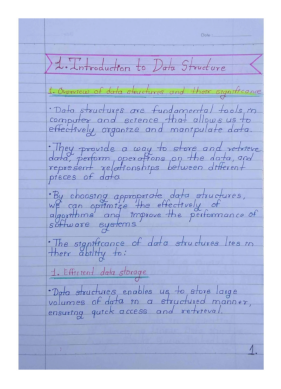

In [5]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread(image_path)

# img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
plt.imshow(img)

plt.axis('off')

plt.show()



In [9]:
import cv2
import numpy as np

def preprocess(img_path):
    img = cv2.imread(img_path)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Noise removal
    blur = cv2.GaussianBlur(gray, (5,5), 0)

    # Thresholding
    thresh = cv2.adaptiveThreshold(
        blur, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        11, 2
    )

    return thresh

In [10]:
processed_img = preprocess(image_path)

In [19]:
# processed_images = []

# for img_path in png_files:
#     processed_img = preprocess(img_path)
#     processed_images.append(processed_img)

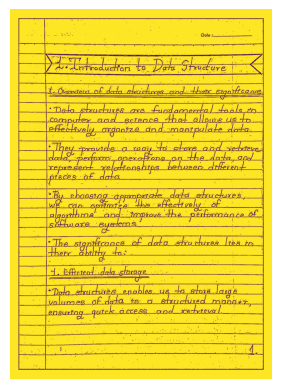

In [11]:
plt.imshow(processed_img)

plt.axis('off')

plt.show()

In [12]:
import pytesseract

text = pytesseract.image_to_string(processed_img)

In [13]:
text

" \n\nG\n\n. Ie fe\nA\nwy i\nwo }\nter\nyi o -\n' .\na oP\nEst ot .\n‘y a:\n| A\n=f\nfoo # ma)\nPood\n| og\n=\nA :\nf\n+ a\n—/ |\na, .\nA .\nom i\n2 .\n~ - | Go .\n. o |\nfom ae\n\n \n\na , rade e . - = ot . Tee “oy . A\n° . ) ye . 5 an oe i ; vl: YG fe afexe. f-\nY a | BS CET ROW: Le = \\\n\x0c"

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def visualize_easyocr(image_path, results):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    for (bbox, text, prob) in results:
        # Convert bbox to integer points
        pts = np.array(bbox, dtype=np.int32)

        # Draw bounding box
        cv2.polylines(img, [pts], isClosed=True, color=(0,255,0), thickness=2)

        x, y = pts[0]
        cv2.putText(img, f"{text} ({prob:.2f})",
                    (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.9, (255,0,0), 1)

    plt.figure(figsize=(10,10))
    plt.imshow(img)
    plt.axis('off')
    plt.title("EasyOCR Detection")
    plt.show()

In [16]:
import easyocr

reader = easyocr.Reader(['en'])
results = reader.readtext(image_path)

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


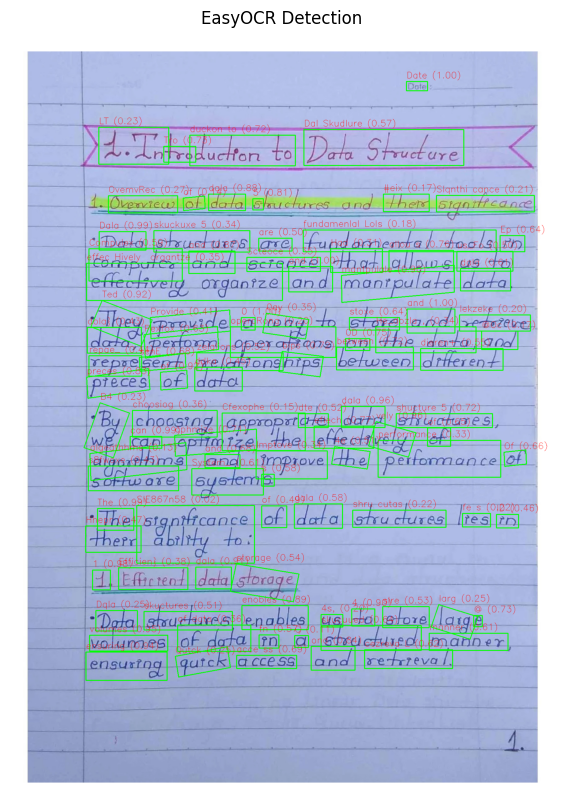

In [17]:
visualize_easyocr(image_path, results)

In [ ]:
from doctr.models import ocr_predictor

model = ocr_predictor(pretrained=True, assume_straight_pages = False)

In [19]:
from doctr.io import DocumentFile

result = model([img])

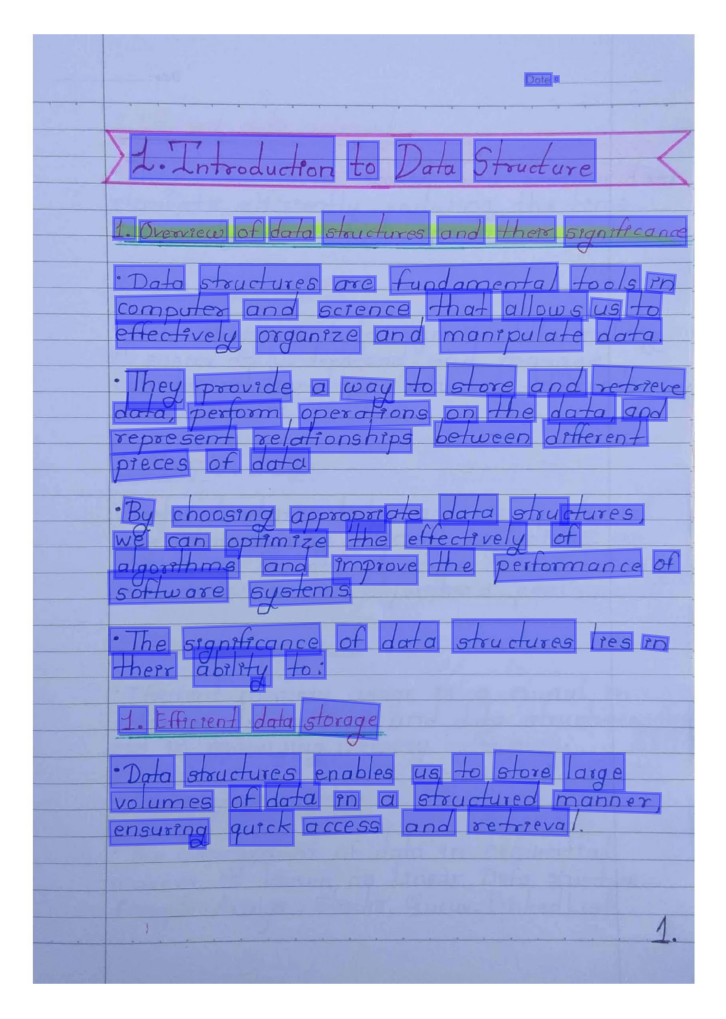

In [20]:
result.show()

In [25]:
# Export the result to a nested dictionary
json_output = result.export()

# Print the extracted text for each word
for page in json_output['pages']:
    for block in page['blocks']:
        for line in block['lines']:
            for word in line['words']:
                print(word['value'], end=' ')

Date - .Introductton to Data Shucture 1. Oveniew of data clauctures and thets signiticane Data stouctures ce fundamental tools PD Computer and Science that allows us to effectively organtze and mantpulate data. They Provide a way to store and retsteve data, pertorm operattons on the data, PUD represent gelationsbtps between different pieces of datal By choosing appropot dte data shuc ctures, aM can optimize the effecttvely of algoatthms ang Improve the pertormance of softwore systems The stantftcance of data structures res rD theer abiltty to: d 1. Effietent data storage -Data stauctures enables us to store laige volumes of data in a stouctured manner, ensurfng qutck access and retrreva a 